# **Damage propagation in a U-bolt:**
In the following parts we will focus on the problem of damage propagation over time. In the following lines of code we will upload the data computed by solving a **F.O.M.**.
This high fidelity solutions are computed starting from the **Fisher-KPP** equation:
<br><br><br>
$$
\begin{cases}
\frac{\partial u}{\partial t} - D \Delta u = r u(1-u) & \text{in } \Omega \times (0,T], \\
\nabla u \cdot \mathbf{n} = 0 & \text{on } \partial \Omega \times (0,T], \\
u(\cdot, 0) = g_\delta & \text{in } \Omega,
\end{cases}
$$
<br><br><br>
where $D > 0$ and $r > 0$ are the **diffusion and reaction coefficients**, respectively, whereas $\delta > 0$ is a parameter describing the location of **the initial damage**. While, the solution $u : \Omega \times [0, T] \rightarrow [0, 1]$ indicates the level of damage:

*   $u$ equal to $1$ indicates maximum damage
*   $u$ equal to $0$ indicates no damage



 Then for $g_\delta$ we have that:


$$
g_\delta(x,y) :=
\begin{cases}
1 & \text{if } |x - \delta| < 0.1 \text{ and } y \geq 4, \\
0 & \text{otherwise}.
\end{cases}
$$


For the sake of our analysis, we parametrize the model coefficients as


$$
D = 10^{\mu_1}, \quad r = 10^{\mu_2 + 2}, \quad \delta = \mu_3 + 1,
$$


where $\mu = [\mu_1, \mu_2, \mu_3]^\top$ varies in $[0,1]^3$. The final time is set to $T = 0.02$.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import time
from IPython.display import clear_output as clc
import torch
from torch import tanh
from torch.optim import Adam

In [ ]:
# Fancy colormap for plotting
from matplotlib.colors import ListedColormap
import matplotlib as mpl
jet = mpl.colormaps['jet']
jet_colors = jet(np.linspace(0, 1, 256))
def modify_jet_to_gray(jet_colors):
    new_colors = jet_colors.copy()
    gray_vals = np.linspace(0.3, 0.7, 85)
    for i in range(85):
        new_colors[i, 0:3] = gray_vals[i]
    return ListedColormap(new_colors)
gray_jet = modify_jet_to_gray(jet_colors)

In [ ]:
# FOM discretization
import gdown
gdown.download(id = "1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX", output = "ubolt_mesh.xml")
mesh = fe.loadmesh("ubolt_mesh.xml")
Vh = fe.space(mesh, 'CG', 1)

Downloading...
From (original): https://drive.google.com/uc?id=1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX
From (redirected): https://drive.google.com/uc?id=1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX&confirm=t&uuid=8027266c-053b-4b1f-b9b9-39d41f9508cf
To: /content/ubolt_mesh.xml
100%|██████████| 1.33M/1.33M [00:00<00:00, 41.4MB/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.



Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_3801828c0f66b7190a7fd5819465b3d5b34b9149

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00553298 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.497281 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:---------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#now we load from the drive the dataset that we have already computed
#load_path = "/content/drive/MyDrive/Colab Notebooks/MODEL ORDER REDUCTION TECHNIQUES/ASSIGNEMENT_2/" #michele
load_path = "/content/drive/MyDrive/Colab Notebooks/ASSIGNEMENT_2/ASSIGNEMENT_2/" #mamma
mu = np.load(load_path + "mu.npy")
ufom = np.load(load_path + "ufom.npy")
clc()
print(f"The shape of the parameters, mu, is: {mu.shape}")
print(f"The shape of the uFom solution is: {ufom.shape}")
print(f"In particular:")
print(f"The number of simulation, Ns, is: {ufom.shape[0]}")
print(f"The number of time step per each simulation, Nt, is: {ufom.shape[1]}")
print(f"The number of mesh nodes, Nh, is: {ufom.shape[2]}")

The shape of the parameters, mu, is: (100, 3)
The shape of the uFom solution is: (100, 41, 6636)
In particular:
The number of simulation, Ns, is: 100
The number of time step per each simulation, Nt, is: 41
The number of mesh nodes, Nh, is: 6636


In [ ]:
#we immediately pass to tensors
mu, ufom = dv.tensor(mu, ufom)

In [ ]:
#we try to see how is the singular value decay even if we know that we will not use POD-GALERKIN
ntraining = 75
ntest = 25
nvalidation = int(ntraining*0.2) #this is used to avoid overfitting wiht the training data
Ns = ufom.shape[0] #the number of simulations
Nt = ufom.shape[1] #the number of time istances
Nh = ufom.shape[2] #the number of nodes
p = mu.shape[1] #the number of parameters
delta_t = 0.0005

In [ ]:
l2 = L2(Vh) #we create the norm  and it expects input like ... x Nh
l2.cuda()
clc()

In [ ]:
#now we define the error function that we will use several times in the code

def error_func(utrue, upred):
  #we must have data written as ... x Nh, otherwise L2 doesn't work
  current_Ns = utrue.shape[0]//Nt #because this will enter also in the training and there Ns is 75
  error =  (l2(utrue-upred).reshape(current_Ns, Nt)/l2(utrue).reshape(current_Ns, Nt)).mean(axis = -1)
  error = error.mean()
  return error

In [ ]:
#WE CANNOT USE POD + GALERKIN BECAUSE THE PROBLEM IS NON LINEAR AND NON AFFINE AND SO IF WE STILL WANT TO BUILD A ROM WE MUST USE HYPER REDUCTION TECHNIQUES THAT ARE VERY EXPENSIVE

# **Construction of POD-AE-SINDy:**
The **Fisher-KPP** equation is characterized by nonlinear terms and the parameters enter in the equation in a non affine way. So, instead of using **hyper-reduction techniques**, we exploit **neural networks**. In this case the strategy that is adopted is the **POD-AE-SINDy**. This is composed by:

*   **POD** to find $V\in\mathbb{R}^{N_h\times N}$
*   **small-encoder**, $\Psi':\mathbb{R}^{N}\to\mathbb{R}^{n}$ with $\Psi'(\mathbf{u}):=\psi'(\mathbf{V}^\top\mathbf{u})$

*   **small-decoder**, $\Psi:\mathbb{R}^{n}\to\mathbb{R}^{N}$ with $\Psi(\mathbf{z}):=\mathbf{V}\psi(\mathbf{z})$

So now we have simply trained a network that allows us to pass from Nh, passing through N, to latent (n). N is selected looking at the singular value decay of the POD. While latent is selected knowing that $p \leq n \leq 2p + 1 $, but because our problem is time dependent inside p we have to consider also **time**. So at the end we selected for the latent dimension $p + 1$. Not $2(p+1) + 1$ because now we would like to work with the smallest number of variables in the latent dimension and so we decided for that.
Then, we have to reconstruct the dynamics at the latent level and so we use the **SINDy** (sparse identification of non linear dynamics). Basically we write that:
$$\partial_t\mathbf{z}_{\boldsymbol{\mu}}=\mathbf{A}_{\boldsymbol{\mu}}\Xi(\mathbf{z}),$$
where
- The first ingredient is the library $\Xi=[f_1,\dots, f_m]$ consisting of $m$ functions $f_i=f_i(\mathbf{z})$. The library will serve to compute the candidate terms appearing in the evolution equation;

- The second ingredient is a neural network model $\eta:\mathbb{R}^p\to\mathbb{R}^{n\times m}$. The latter will be used to predict the dynamics coefficients associated to each parametric configuration, contained in matrix $A_{\mu}$.





In [ ]:
from scipy.linalg import svd
ufom_PODAESindy = ufom.reshape(-1, Nh)
ntrain_PODAESindy = ntraining*Nt
nvalid_PODAESindy = nvalidation*Nt

#ufom_PODAESindy = ufom.reshape(-1, Nh)
#ntrain_PODAESindy = ntraining*Nt
#nvalid_PODAESindy = nvalidation*Nt

In [ ]:
#we perform the svd

#so we know that to use svd we have to put everything into a 2D numpy array and with dimension Nh x Ns*Nt
U_PODAESindy = ufom.detach().cpu().numpy()
U_PODAESindy = U_PODAESindy[:ntraining, :, :]
U_PODAESindy = np.reshape(U_PODAESindy, (-1, Nh))
U_PODAESindy = U_PODAESindy.T


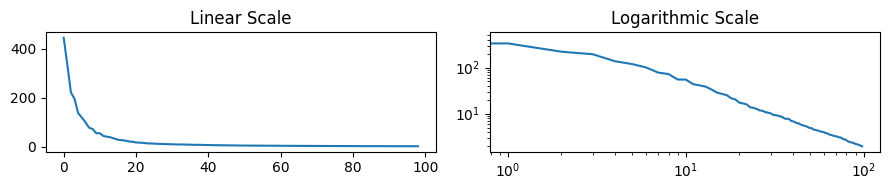

In [ ]:
#we perform the svd
X_PODAESindy, s_PODAESindy, Yt_PODAESindy = svd(U_PODAESindy, full_matrices = False)

#now we create our basis by looking at the singular values
plt.figure(figsize = (9, 2))
plt.subplot(1,2,1)
plt.plot(s_PODAESindy[1:100])
plt.title('Linear Scale')
plt.subplot(1,2,2)
plt.loglog(s_PODAESindy[1:100])
plt.title('Logarithmic Scale')
plt.tight_layout()
plt.show()

In [ ]:
print(s_PODAESindy.shape)
N_PODAESindy = 150 #2*(p + 1) + 1 #WE HAVE TO USE A BIGGER N TO OBTAIN A GOOD RESULT IN TERMS OF ACCURACY, BUT OF COURSE THIS WILL SLOW DOWN THE COMPUTATIONS
energy = np.sum(s_PODAESindy[:N_PODAESindy])/np.sum(s_PODAESindy)
print(f"If we choose N = {N_PODAESindy} we are keeping this energy: {energy*100}%")
#we can see that with a good number of number of basis function we can have a good usage of the energy, however we are not able to

(3075,)
If we choose N = 150 we are keeping this energy: 99.04660034179688%


In [ ]:
#now we compute the projection error to see how is our choice of the vector V
V_PODAESindy = X_PODAESindy[:, :N_PODAESindy]
V_PODAESindy = dv.tensor(V_PODAESindy)

print(V_PODAESindy.shape)
print(ufom_PODAESindy[ntrain_PODAESindy:].shape)
print("POD MRE: %s" % num2p(error_func(ufom_PODAESindy[ntrain_PODAESindy:], ufom_PODAESindy[ntrain_PODAESindy:] @ V_PODAESindy @ V_PODAESindy.T)))

torch.Size([6636, 150])
torch.Size([1025, 6636])
POD MRE: 0.69%


In [ ]:
#now we compute the reduced ufom
ufom_PODAESindy_reduced = ufom_PODAESindy @ V_PODAESindy
print(ufom_PODAESindy_reduced.shape)

torch.Size([4100, 150])


In [ ]:
from torch import tanh
rho = lambda x: tanh(0.01*x) ### <-- smooth activation that bounds the dynamics within [-1,1]^n

latent = p+1
small_encoder = Dense(N_PODAESindy, 40, gelu) + Dense(40, latent, rho)
small_decoder = Dense(latent, 40, gelu) + Dense(40, 100, gelu) + Dense(100, N_PODAESindy, activation = None)
small_ae = DFNN(small_encoder + small_decoder) ### <--- inner AE module, combining the "small encoder" and "small decoder"

small_ae.unfreeze()
small_ae.He()
small_ae.cuda()
small_ae.train(ufom_PODAESindy_reduced, ufom_PODAESindy_reduced, loss = mse(euclidean), ntrain = ntrain_PODAESindy, epochs = 500)
small_ae.freeze()

		Train		Test
Epoch 500:	2.55e-01	6.43e-01.

>> ETA: 0.28s.

Training complete. Elapsed time: 2 minutes 20.92 seconds.


In [ ]:
from dlroms.dnns import Matrix

encoder = Matrix(V_PODAESindy.T) + small_encoder
decoder = small_decoder + Matrix(V_PODAESindy)
ae = encoder + decoder

In [ ]:
print("POD MRE: %s" % num2p(error_func(ufom_PODAESindy[ntrain_PODAESindy:], ae(ufom_PODAESindy[ntrain_PODAESindy:]))))

POD MRE: 2.68%


In [ ]:
from dlroms.dnns import Weightless
from torch import matmul

class Library(Weightless):
  def __init__(self, lib):
    super(Library, self).__init__()
    self.lib = lib

  def forward(self, x):
    from torch import cat
    nx = len(x)
    return cat([f(x).reshape(nx, -1) for f in self.lib], axis = -1)

class SINDy(ROM):
  def __init__(self, *args, **kwargs):
    from torch.nn import Parameter
    super(SINDy, self).__init__(*args, **kwargs)
    self.thr = Parameter(dv.tensor(0.0))

  def threshold(self, A0):
    # Hard-promotes sparsity by clamping values close to 0 (with a learnable threshold)
    return relu(A0-self.thr) - relu(-A0-self.thr)

  def A(self, mu):
    eta = self[0]
    A0 = eta(mu)
    return self.threshold(A0)

  def forward(self, mu, z):
    A = self.A(mu)
    theta = self.Xi(z).unsqueeze(-1)
    return matmul(A, theta).squeeze(-1), A

  def freeze(self, *args, **kwargs):
    super(SINDy, self).freeze(*args, **kwargs)
    self.thr.requires_grad_(False)

  def unfreeze(self, *args, **kwargs):
    super(SINDy, self).freeze(*args, **kwargs)
    self.thr.requires_grad_(True)

  def evolve(self, mu0, z0, steps, tau):
    from torch import atleast_2d
    mu0s = atleast_2d(mu0)
    z0s = atleast_2d(z0)

    many, n = z0s.shape
    zsindy = self.coretype().zeros(many, steps + 1, n)
    zsindy[:, 0] = z0s
    for j in range(steps):
      dzdtj = self.forward(mu0s, zsindy[:, j])[0]
      zsindy[:, j+1] = zsindy[:, j] + tau*dzdtj

    return zsindy

  def parameters(self, *args, **kwargs):
    return super(SINDy, self).parameters() + [self.thr]

  def He(self, *args, **kwargs):
    from torch.nn import Parameter
    super(SINDy, self).He(*args, **kwargs)
    self.thr = Parameter(dv.tensor(0.0))

In [ ]:
def dt(zval):
  """Approximation of time derivatives via finite differences.
  Later used in the definition of the loss to approximate the true derivatives."""
  tau = 0.0005
  zprev = zval.reshape(-1, Nt, latent)[:, :-2, :].reshape(-1, latent)
  znext = zval.reshape(-1, Nt, latent)[:, 2: ,  :].reshape(-1, latent) ### <--- latent state at time instant "i+1", for each sample in the batch
  dzdt = (znext-zprev)/(2*tau)
  return dzdt

In [ ]:
from dlroms.dnns import Reshape
Xi = Library([lambda x: x, lambda x: x**2, lambda x:  x[:, 0]*x[:, 1], lambda x:  x[:, 1]*x[:, 2], lambda x:  x[:, 0]*x[:, 2],  lambda x:  x[:, 0]*x[:, 3],  lambda x:  x[:, 1]*x[:, 3],  lambda x:  x[:, 2]*x[:, 3], lambda x: 1.0 + 0*x])
#Xi = Library([lambda x: x, lambda x: x**2, lambda x: 1.0 + 0*x])

m = Xi(dv.zeros(1, latent)).shape[-1]
p = mu.shape[-1]

eta = Dense(p, 18, gelu) + Dense(18, m*latent, None) + Reshape(latent, m)
sindy = SINDy(eta, Xi = Xi)
sindy.He()
sindy.cuda()

In [ ]:
print(m*latent)

72


In [ ]:
from torch.optim import Adam
def sindy_loss(ztrue, sindy_output):
  dzpred, A = sindy_output
  dzdt_true = dt(ztrue) ### <-- time derivatives of the true latent coordinates
  return mse(euclidean)(dzdt_true, dzpred.reshape(-1, Nt, latent)[:, 1:-1].reshape(-1, latent)) + 0.01*A.abs().tanh().sum(axis = -1).sum(axis = -1).mean() # promotes sparsity via l1-penalty

def sindy_error(ztrue, sindy_output):
  dzpred, A = sindy_output
  dzdt_true = dt(ztrue) ### <-- time derivatives of the true latent coordinates
  return mse(euclidean)(dzdt_true, dzpred.reshape(-1, Nt, latent)[:, 1:-1].reshape(-1, latent))

z_TRUE =  encoder(ufom_PODAESindy)
mu_repeated = (dv.zeros(Ns, Nt, 1) + mu.reshape(Ns, 1, -1)).reshape(Ns*Nt, -1) ### <--- transforming [mu0, mu1, mu2, ...] onto [mu0, .., mu0, mu1, ... mu1, mu2, ....] for shape consistency with z
sindy.train((mu_repeated, z_TRUE), z_TRUE, loss = sindy_loss, error = sindy_error, epochs = 50, ntrain = ntrain_PODAESindy)
sindy.train((mu_repeated, z_TRUE), z_TRUE, loss = sindy_loss, error = sindy_error, epochs = 500, ntrain = ntrain_PODAESindy, optim = Adam, lr = 1e-3, batchsize = Nt, shuffle = False)

		Train		Test
Epoch 500:	2.70e+02	4.50e+02.

>> ETA: 0.22s.

Training complete. Elapsed time: 1 minutes 52.06 seconds.


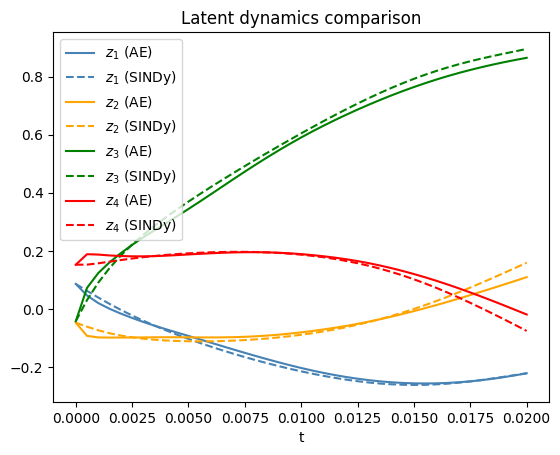

In [ ]:
sindy.freeze()

ztrue = encoder(ufom_PODAESindy).reshape(-1, Nt, latent)
z0s = ztrue[:, 0]
zsindy = sindy.evolve(mu_repeated.reshape(Ns, Nt, -1)[:, 0], z0s, steps = Nt-1, tau = 0.0005)
t = np.arange(Nt)*0.0005
which = -2
plot(t, ztrue[which, :, 0], color = 'steelblue', label = '$z_1$ (AE)')
plot(t, zsindy[which, :, 0], '--', color = 'steelblue', label = '$z_1$ (SINDy)')
plot(t, ztrue[which, :, 1], color = 'orange', label = '$z_2$ (AE)')
plot(t, zsindy[which, :, 1], '--', color = 'orange', label = '$z_2$ (SINDy)')
plot(t, ztrue[which, :, 2], color = 'green', label = '$z_3$ (AE)')
plot(t, zsindy[which, :, 2], '--', color = 'green', label = '$z_3$ (SINDy)')
plot(t, ztrue[which, :, 3], color = 'red', label = '$z_4$ (AE)')
plot(t, zsindy[which, :, 3], '--', color = 'red', label = '$z_4$ (SINDy)')
plt.legend()
plt.xlabel("t")
plt.title("Latent dynamics comparison")
None

In [ ]:
print("AE MRE: %s" % num2p(error_func(ufom_PODAESindy[ntrain_PODAESindy:, :], ae(ufom_PODAESindy[ntrain_PODAESindy:, :])))) #ae_AESindy(ufom_AESindy[ntrain_AESindy:]))))
print("AE + SINDy MRE: %s" % num2p(error_func(ufom_PODAESindy[ntrain_PODAESindy:], decoder(zsindy.reshape(Ns*Nt, -1)[ntrain_PODAESindy:])))) #decoder_AESindy(zsindy.reshape(Ns*Nt, -1)[ntrain_AESindy:])))) ### <--- AE + SINDy approximations obtained by decoding sindy evolved states
print("AE + SINDy MRE on the last simulation: %s" % num2p(error_func(ufom_PODAESindy[-Nt:], decoder(zsindy.reshape(Ns*Nt, -1)[-Nt:]))))

AE MRE: 2.68%
AE + SINDy MRE: nan%
AE + SINDy MRE on the last simulation: 12.75%


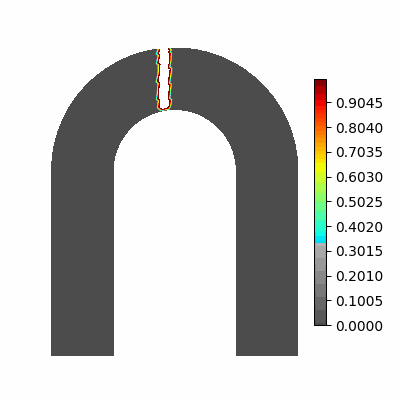

In [ ]:
#FOM SOLUTION
fe.animate(ufom[99, :, :], Vh, cmap = gray_jet, colorbar = True)

torch.Size([4100, 6636])


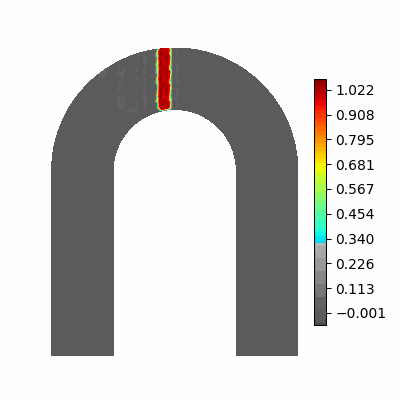

In [ ]:
#ROM SOLUTION
uROM_AESindy = decoder(zsindy.reshape(Ns*Nt, -1))
print(uROM_AESindy.shape)
uROM_AESindy = uROM_AESindy.reshape(Ns, Nt, Nh)
fe.animate(uROM_AESindy[99, :, :], Vh, cmap = gray_jet, colorbar = True)


In [ ]:
#save_path = "/content/drive/MyDrive/Colab Notebooks/MODEL ORDER REDUCTION TECHNIQUES/ASSIGNEMENT_2/" #michele
save_path = "/content/drive/MyDrive/Colab Notebooks/ASSIGNEMENT_2/ASSIGNEMENT_2/" #mamma

In [ ]:
#we save our autoencoder to use it in other notebooks
torch.save(sindy.state_dict(), save_path + "sindy.pt")
torch.save(small_ae.state_dict(), save_path + "small_ae_sindy.pt")
torch.save(V_PODAESindy, save_path + "V_PODAESindy.pt")
np.save(save_path + "N_PODAESindy.npy", N_PODAESindy)